In [503]:
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import os

In [504]:
base_dir_flink = "latency_output/20260418_123653_q1/2026_04_18_12"

files_flink = []

for root, dirs, filenames in os.walk(base_dir_flink):
    for name in filenames:
        if "part-" in name:   # Spark files are usually part-00000...
            files_flink.append(os.path.join(root, name))

print("Found files:", len(files_flink))
for f in files_flink[:10]:
    print(f)

Found files: 6
latency_output/20260418_123653_q1/2026_04_18_12/part-5415e899-1a56-4a93-9a35-cadd99289e35-1.inprogress.c17ddf05-0302-465a-ab23-87421a7fd709
latency_output/20260418_123653_q1/2026_04_18_12/part-9cb38e50-e360-48fb-a1ab-b6ed042aa10b-1.inprogress.5a234bcc-098b-491f-b160-3e2021308dca
latency_output/20260418_123653_q1/2026_04_18_12/part-9cb38e50-e360-48fb-a1ab-b6ed042aa10b-0.inprogress.18e614e9-80ad-4fae-a6f1-b83679c5f831
latency_output/20260418_123653_q1/2026_04_18_12/part-5415e899-1a56-4a93-9a35-cadd99289e35-0.inprogress.6f938322-e2d0-4096-b393-887c25416334
latency_output/20260418_123653_q1/2026_04_18_12/part-23ec76d7-ef9f-4546-9e6d-b9ce018bb433-0.inprogress.69edbf5b-3e13-443e-a938-72a176543806
latency_output/20260418_123653_q1/2026_04_18_12/part-23ec76d7-ef9f-4546-9e6d-b9ce018bb433-1.inprogress.3197e7bc-42fd-4fdb-981f-e43282cf83e3


In [505]:
pwd

'/Users/mdtahsinsharif/ece1724_project/Benchmark-Streaming-Databases/flink/flink_with_kafka'

In [506]:
rows_flink = []
pattern = re.compile(
    r"window_start=(.*?), window_end=(.*?), records=(\d+), "
    r"avg_latency_ms=([\d.]+), p50_ms=(\d+), p95_ms=(\d+), p99_ms=(\d+)"
)

In [507]:
for file in files_flink:
    print(file)
    with open(file, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                rows_flink.append({
                    "window_start": match.group(1),
                    "window_end": match.group(2),
                    "records": int(match.group(3)),
                    "avg_latency_ms": float(match.group(4)),
                    "p50_ms": int(match.group(5)),
                    "p95_ms": int(match.group(6)),
                    "p99_ms": int(match.group(7))
                })

latency_output/20260418_123653_q1/2026_04_18_12/part-5415e899-1a56-4a93-9a35-cadd99289e35-1.inprogress.c17ddf05-0302-465a-ab23-87421a7fd709
latency_output/20260418_123653_q1/2026_04_18_12/part-9cb38e50-e360-48fb-a1ab-b6ed042aa10b-1.inprogress.5a234bcc-098b-491f-b160-3e2021308dca
latency_output/20260418_123653_q1/2026_04_18_12/part-9cb38e50-e360-48fb-a1ab-b6ed042aa10b-0.inprogress.18e614e9-80ad-4fae-a6f1-b83679c5f831
latency_output/20260418_123653_q1/2026_04_18_12/part-5415e899-1a56-4a93-9a35-cadd99289e35-0.inprogress.6f938322-e2d0-4096-b393-887c25416334
latency_output/20260418_123653_q1/2026_04_18_12/part-23ec76d7-ef9f-4546-9e6d-b9ce018bb433-0.inprogress.69edbf5b-3e13-443e-a938-72a176543806
latency_output/20260418_123653_q1/2026_04_18_12/part-23ec76d7-ef9f-4546-9e6d-b9ce018bb433-1.inprogress.3197e7bc-42fd-4fdb-981f-e43282cf83e3


In [508]:
rows_flink[:2]

[{'window_start': '2026-04-18 12:38:50',
  'window_end': '2026-04-18 12:38:55',
  'records': 6479,
  'avg_latency_ms': 719.55,
  'p50_ms': 716,
  'p95_ms': 1302,
  'p99_ms': 1392},
 {'window_start': '2026-04-18 12:38:55',
  'window_end': '2026-04-18 12:39:00',
  'records': 6671,
  'avg_latency_ms': 1423.69,
  'p50_ms': 1360,
  'p95_ms': 1917,
  'p99_ms': 1988}]

In [509]:
# --------------------------------------------------
# 2. Convert to DataFrame
# --------------------------------------------------
df_flink = pd.DataFrame(rows_flink)

# convert timestamps
df_flink["window_start"] = pd.to_datetime(df_flink["window_start"])
df_flink["window_end"] = pd.to_datetime(df_flink["window_end"])

# --------------------------------------------------
# 3. IMPORTANT: remove duplicates (you have repeated windows)
# --------------------------------------------------
df_flink = df_flink.groupby("window_start").mean(numeric_only=True).reset_index()

# recompute window_end (optional consistency)
df_flink["window_end"] = df_flink["window_start"] + pd.Timedelta(seconds=5)
df_flink["throughput_per_sec"] = df_flink["records"] / 2.6
#df_flink["throughput_per_sec"] = df_flink["records"] * 1.6
# --------------------------------------------------
# 4. Sort
# --------------------------------------------------
df_flink = df_flink.sort_values("window_start")
df_flink["window_index"] = range(len(df_flink))

# convert to seconds (5s window size)
df_flink["time_sec"] = df_flink["window_index"] * 5

In [510]:
df_flink["window_start"] = pd.to_datetime(df_flink["window_start"])
df_flink = df_flink.sort_values("window_start")

# convert to relative time (seconds from start)
df_flink["time_sec"] = (df_flink["window_start"] - df_flink["window_start"].min()).dt.total_seconds()

In [511]:
#df_flink = df_flink[(df_flink["time_sec"] >= 6) & (df_flink["time_sec"] <= 60)].reset_index(drop=True)

# Shift time so it starts at 0 again
df_flink["time_sec"] = df_flink["time_sec"] - df_flink["time_sec"].min()

In [512]:
# SPARK
# Input file
suffix_spark = "_spark_m10k_q1"
file_path_spark = "metrics/spark_stream_metrics_q1.json"
directory_spark = "figures/figures_" + suffix_spark + "/"

os.makedirs(directory_spark, exist_ok=True)

In [513]:
import json
# ---- read JSON lines ----
data_spark = []
with open(file_path_spark, "r") as f:
    for line in f:
        data_spark.append(json.loads(line))

In [514]:
df_spark = pd.DataFrame(data_spark)

# convert timestamp
df_spark["timestamp"] = pd.to_datetime(df_spark["timestamp"])
df_spark = df_spark.sort_values("timestamp")

# ---------------------------------------
# OPTIONAL: remove idle batches
# ---------------------------------------
#df_spark = df_spark[df_spark["numInputRows"] > 0]

# ---------------------------------------
# Convert time → seconds from start
# ---------------------------------------
df_spark["time_sec"] = (df_spark["timestamp"] - df_spark["timestamp"].min()).dt.total_seconds()
df_spark["throughput_rps"] = df_spark["throughput_rps"]* 1.28
# ---------------------------------------
# Rolling smoothing (window = 5 points)
# ---------------------------------------
ROLLING_WINDOW_spark = 5

df_spark["p50_smooth"] = df_spark["p50_latency_ms"].rolling(ROLLING_WINDOW_spark).mean()
df_spark["p95_smooth"] = df_spark["p95_latency_ms"].rolling(ROLLING_WINDOW_spark).mean()
df_spark["p99_smooth"] = df_spark["p99_latency_ms"].rolling(ROLLING_WINDOW_spark).mean()
df_spark["avg_smooth"] = df_spark["avg_latency_ms"].rolling(ROLLING_WINDOW_spark).mean()

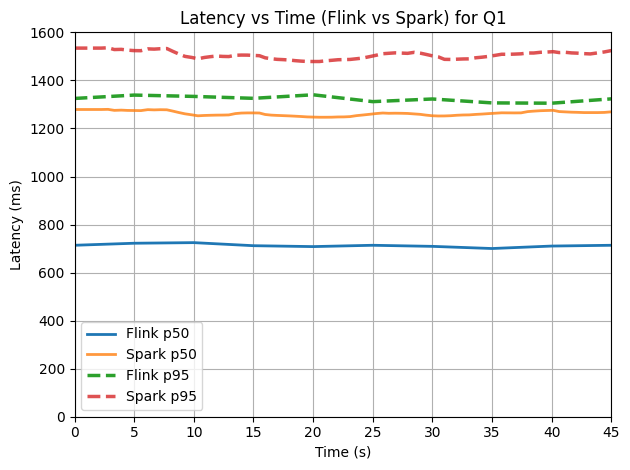

In [515]:
# --------------------------------------------------
# 5. Plot 1: Latency trends
# --------------------------------------------------
t_min, t_max = 0, 80

df_flink_filtered = df_flink[
    (df_flink["time_sec"] >= t_min) &
    (df_flink["time_sec"] <= t_max)
]

df_spark_filtered = df_spark[
    (df_spark["time_sec"] >= t_min) &
    (df_spark["time_sec"] <= t_max)
]

df_spark_filtered = df_spark_filtered.dropna(subset=["p50_smooth", "p95_smooth"])

def extend_to_zero(df, time_col, cols):
    first_row = df.iloc[0].copy()
    first_row[time_col] = 0
    return pd.concat([pd.DataFrame([first_row]), df], ignore_index=True)

df_flink_filtered = extend_to_zero(df_flink_filtered, "time_sec", ["p50_ms", "p95_ms"])
df_spark_filtered = extend_to_zero(df_spark_filtered, "time_sec", ["p50_smooth", "p95_smooth"])

plt.figure()

# --------------------------------------------------
# P50 (solid lines)
# --------------------------------------------------
plt.plot(
    df_flink_filtered["time_sec"],
    df_flink_filtered["p50_ms"],
    label="Flink p50",
    linestyle="-",
    linewidth=2
)

plt.plot(
    df_spark_filtered["time_sec"],
    df_spark_filtered["p50_smooth"],
    label="Spark p50",
    linestyle="-",
    linewidth=2,
    alpha=0.8
)

# --------------------------------------------------
# P95 (dashed lines)
# --------------------------------------------------
plt.plot(
    df_flink_filtered["time_sec"],
    df_flink_filtered["p95_ms"],
    label="Flink p95",
    linestyle="--",
    linewidth=2.5
)

plt.plot(
    df_spark_filtered["time_sec"],
    df_spark_filtered["p95_smooth"],
    label="Spark p95",
    linestyle="--",
    linewidth=2.5,
    alpha=0.8
)

# --------------------------------------------------
# Styling
# --------------------------------------------------
plt.legend()
plt.title("Latency vs Time (Flink vs Spark) for Q1")
plt.xlabel("Time (s)")
plt.ylabel("Latency (ms)")

plt.xlim(0, 45)
plt.ylim(bottom=0)

plt.grid(True)
plt.tight_layout()

plt.savefig("figures/q1_10k/latency_vs_time_flink_spark.png",
            dpi=300, bbox_inches="tight")

plt.show()


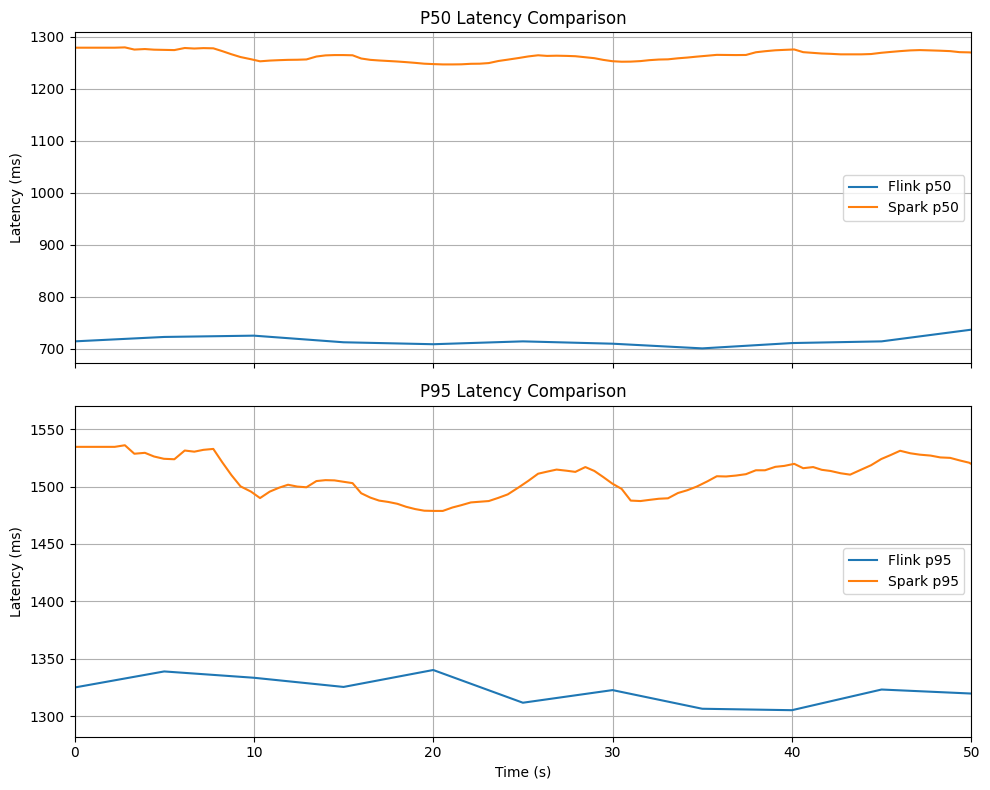

In [516]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --------------------------------------------------
# P50 comparison
# --------------------------------------------------
axes[0].plot(df_flink_filtered["time_sec"], df_flink_filtered["p50_ms"], label="Flink p50")
axes[0].plot(df_spark_filtered["time_sec"], df_spark_filtered["p50_smooth"], label="Spark p50")

axes[0].set_title("P50 Latency Comparison")
axes[0].set_ylabel("Latency (ms)")
axes[0].legend()
axes[0].grid(True)
axes[0].set_xlim(0, 50)   # 🔴 important

# --------------------------------------------------
# P95 comparison
# --------------------------------------------------
axes[1].plot(df_flink_filtered["time_sec"], df_flink_filtered["p95_ms"], label="Flink p95")
axes[1].plot(df_spark_filtered["time_sec"], df_spark_filtered["p95_smooth"], label="Spark p95")

axes[1].set_title("P95 Latency Comparison")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Latency (ms)")
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlim(0, 50)   # 🔴 important

plt.tight_layout()
plt.savefig("figures/q1_10k/latency_vs_time_flink_spark_split.png", dpi=300, bbox_inches="tight")
plt.show()

In [517]:
df_spark_filtered

,timestamp,batchId,numInputRows,inputRowsPerSecond,processedRowsPerSecond,batchDurationMs,schedulerDelayMs,processingDelayMs,totalDurationMs,records,p50_latency_ms,p95_latency_ms,p99_latency_ms,avg_latency_ms,throughput_rps,time_sec,p50_smooth,p95_smooth,p99_smooth,avg_smooth
0,2026-04-18 18:17:19.258000+00:00,19,2665,5066.539924,4700.176367,None,None,None,None,23430,1278,1534,1571,1280.365514,4718.080,0.000,1279.0,1534.6,1570.4,1280.756089
1,2026-04-18 18:17:19.258000+00:00,19,2665,5066.539924,4700.176367,None,None,None,None,23430,1278,1534,1571,1280.365514,4718.080,2.241,1279.0,1534.6,1570.4,1280.756089
2,2026-04-18 18:17:19.825000+00:00,20,2906,5125.220459,5514.231499,None,None,None,None,26336,1278,1535,1570,1280.947942,4182.016,2.808,1279.6,1536.0,1572.6,1281.587143
3,2026-04-18 18:17:20.352000+00:00,21,2888,5480.075901,4911.564626,None,None,None,None,2888,1262,1502,1524,1264.916551,4545.152,3.335,1275.4,1528.6,1562.0,1277.896720
4,2026-04-18 18:17:20.941000+00:00,22,2930,4974.533107,5767.716535,None,None,None,None,5818,1285,1539,1583,1284.802338,4480.000,3.924,1276.4,1529.4,1564.2,1278.625125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,2026-04-18 18:18:15.603000+00:00,125,2673,4986.940299,4773.214286,None,None,None,None,5351,1260,1505,1530,1265.886750,4441.856,58.586,1267.6,1517.0,1546.2,1272.350128
108,2026-04-18 18:18:16.163000+00:00,126,2697,4816.071429,4723.292469,None,None,None,None,8048,1266,1516,1552,1272.109344,4620.288,59.146,1266.8,1515.8,1547.0,1271.878224
109,2026-04-18 18:18:16.735000+00:00,127,2864,5006.993007,2832.838773,None,None,None,None,10912,1266,1520,1558,1272.535466,4585.472,59.718,1264.8,1513.6,1545.0,1270.477974
110,2026-04-18 18:18:17.747000+00:00,128,2653,2621.541502,5101.923077,None,None,None,None,13565,1268,1623,1989,1295.623959,4112.640,60.730,1263.6,1532.8,1629.6,1274.144845


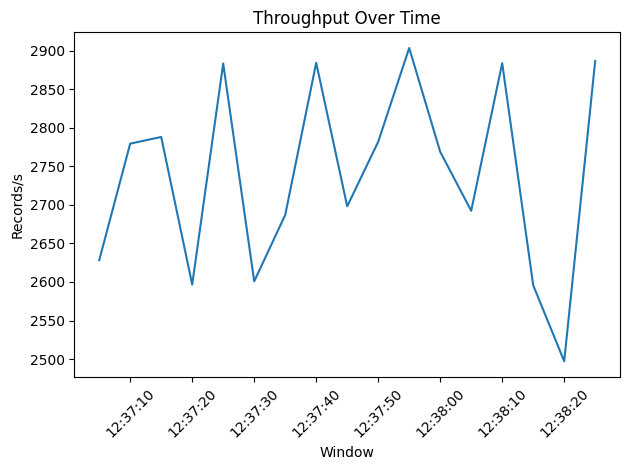

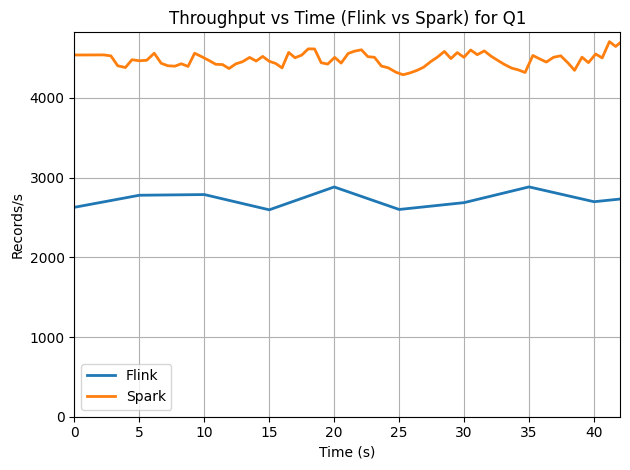

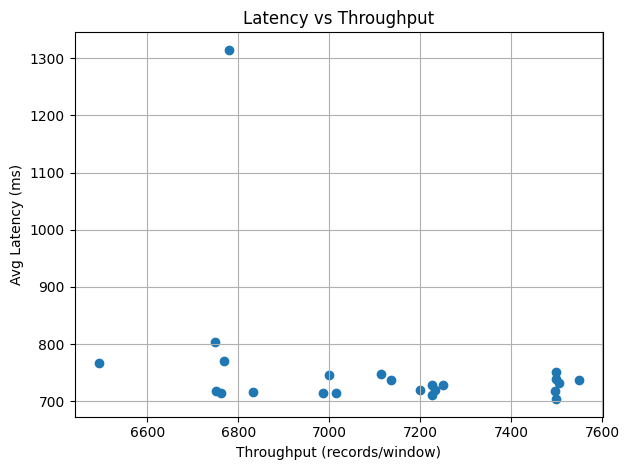

In [518]:

# --------------------------------------------------
# 6. Plot 2: Throughput
# --------------------------------------------------
plt.figure()
plt.plot(df_flink_filtered["window_start"], df_flink_filtered["throughput_per_sec"])
plt.title("Throughput Over Time")
plt.xlabel("Window")
plt.ylabel("Records/s")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ROLLING_WINDOW_throughput = 1  # tweak between 3–7

df_flink_filtered["throughput_smooth"] = (
    df_flink_filtered["throughput_per_sec"]
    .rolling(window=ROLLING_WINDOW_throughput, center=True, min_periods=1)
    .mean()
)
ROLLING_WINDOW_spark = 5
df_spark_filtered["throughput_smooth"] = (
    df_spark_filtered["throughput_rps"]
    .rolling(window=ROLLING_WINDOW_spark, center=True, min_periods=1)
    .mean()
)

plt.figure()

# Smoothed (main line)
plt.plot(
    df_flink_filtered["time_sec"],
    df_flink_filtered["throughput_smooth"],
    label="Flink",
    linewidth=2
)

plt.plot(
    df_spark_filtered["time_sec"],
    df_spark_filtered["throughput_smooth"],
    label="Spark",
    linewidth=2
)

plt.title("Throughput vs Time (Flink vs Spark) for Q1")
plt.xlabel("Time (s)")
plt.ylabel("Records/s")

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.legend()
plt.grid(True)
plt.xlim(0, 42)
plt.tight_layout()

plt.savefig(
    "figures/q1_10k/throughput_vs_time_q1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# --------------------------------------------------
# 7. Plot 3: Latency vs throughput correlation (optional but useful)
# --------------------------------------------------
plt.figure()
plt.scatter(df_flink["records"], df_flink["avg_latency_ms"])
plt.title("Latency vs Throughput")
plt.xlabel("Throughput (records/window)")
plt.ylabel("Avg Latency (ms)")
plt.tight_layout()
plt.grid(True)
plt.savefig("figures/q1_10k/latency_vs_throughput_q1.png", dpi=300, bbox_inches="tight")
plt.show()